# Modeling Pipeline: Claim Occurrence and Severity
This notebook builds and evaluates models for:
- Claim occurrence (classification: predict HasClaim)
- Claim severity (regression: predict TotalClaims for cases with HasClaim=1)
It loads processed features, splits data, trains models, evaluates performance, and generates plots and interpretability outputs.


## 1. Imports and Parameters
Load required libraries and parameters from `params.yaml`.


In [18]:
import pandas as pd
import numpy as np
import yaml
import joblib
import os

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score,
    mean_squared_error, r2_score, precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# Load parameters
params_path = "../params.yaml"  # adjust if notebook path differs; here notebook in notebooks/, so "../params.yaml"
with open(params_path) as f:
    params = yaml.safe_load(f)
# Extract train-test split settings
test_size = params.get('train_test_split', {}).get('test_size', 0.3)
random_state = params.get('train_test_split', {}).get('random_state', 42)

# Model hyperparameters
cls_params = params.get('classification', {})
reg_params = params.get('regression', {})

print("Parameters loaded:")
print(f"  test_size = {test_size}, random_state = {random_state}")
print("  Classification params:", cls_params)
print("  Regression params:", reg_params)


Parameters loaded:
  test_size = 0.3, random_state = 42
  Classification params: {'n_estimators': 100, 'max_depth': None, 'class_weight': 'balanced'}
  Regression params: {'n_estimators': 100, 'max_depth': None}


# 2. Load Processed Features
The processed feature set is loaded from features.parquet. This dataset contains all the variables needed for modeling.

In [19]:
features_path = "../data/processed/features.parquet"  # adjust if needed
if not os.path.exists(features_path):
    raise FileNotFoundError(f"features.parquet not found at {features_path}")
df = pd.read_parquet(features_path)
print("Loaded features DataFrame with shape:", df.shape)
# Show first few columns and rows
display(df.head())
# Check that required columns exist:
required_cols = ['HasClaim', 'TotalClaims']
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' missing in features DataFrame")
# Check class balance
counts = df['HasClaim'].value_counts()
print("HasClaim value counts:\n", counts)
print("HasClaim proportions:\n", df['HasClaim'].value_counts(normalize=True))


Loaded features DataFrame with shape: (1000098, 47)


,VehicleAge,kilowatts,Cylinders,log_CustomValueEstimate,Province_Free State,Province_Gauteng,Province_KwaZulu-Natal,Province_Limpopo,Province_Mpumalanga,Province_North West,...,CoverCategory_Third Party,CoverCategory_Third Party Only,CoverCategory_Trailer,CoverCategory_Vehicle over R100 000,CoverCategory_Vehicle under R100 000,CoverCategory_Windscreen,CoverCategory_Windscreen (2015),TermFrequency_Monthly,HasClaim,TotalClaims
0,13.0,130.0,6.0,11.689405,False,True,False,False,False,False,...,False,False,False,False,False,True,False,True,0,0.0
1,13.0,130.0,6.0,11.689405,False,True,False,False,False,False,...,False,False,False,False,False,True,False,True,0,0.0
2,13.0,130.0,6.0,11.689405,False,True,False,False,False,False,...,False,False,False,False,False,True,False,True,0,0.0
3,13.0,130.0,6.0,11.689405,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,0,0.0
4,13.0,130.0,6.0,11.689405,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,0,0.0


HasClaim value counts:
 HasClaim
0    997310
1      2788
Name: count, dtype: int64
HasClaim proportions:
 HasClaim
0    0.997212
1    0.002788
Name: proportion, dtype: float64


# 3. Train/Test Split
The data is split into training and testing sets for both the classification and regression tasks.


In [20]:
# Classification split
X = df.drop(columns=['HasClaim', 'TotalClaims'], errors='ignore')
y_cls = df['HasClaim']
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cls, test_size=test_size, random_state=random_state, stratify=y_cls
)
print("Classification split: X_train, X_test shapes:", X_train.shape, X_test.shape)
print("  y_train distribution:\n", y_train.value_counts(normalize=True))
print("  y_test distribution:\n", y_test.value_counts(normalize=True))

# Regression split on positive cases
df_pos = df[df['HasClaim'] == 1].copy()
print("Number of positive cases for regression:", df_pos.shape[0])
if df_pos.shape[0] < 50:
    print("Warning: too few positive cases for regression training; consider larger dataset.")
Xr = df_pos.drop(columns=['HasClaim', 'TotalClaims'], errors='ignore')
yr = df_pos['TotalClaims']
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=test_size, random_state=random_state
)
print("Regression split: Xr_train, Xr_test shapes:", Xr_train.shape, Xr_test.shape)


Classification split: X_train, X_test shapes: (700068, 45) (300030, 45)
  y_train distribution:
 HasClaim
0    0.997212
1    0.002788
Name: proportion, dtype: float64
  y_test distribution:
 HasClaim
0    0.997214
1    0.002786
Name: proportion, dtype: float64
Number of positive cases for regression: 2788
Regression split: Xr_train, Xr_test shapes: (1951, 45) (837, 45)


# 4. Classification Model: Claim Occurrence
A RandomForestClassifier is trained on the classification training data (X_train, y_train). The model uses the hyperparameters defined earlier, including class_weight='balanced', which adjusts weights inversely proportional to class frequencies to give more importance to the minority class (claims).


In [21]:
# Initialize classifier
rf_cls = RandomForestClassifier(
    n_estimators=cls_params.get('n_estimators', 100),
    max_depth=cls_params.get('max_depth', None),
    class_weight=cls_params.get('class_weight', 'balanced'),
    random_state=random_state,
    n_jobs=-1
)
# Train
print("Training RandomForestClassifier...")
rf_cls.fit(X_train, y_train)
print("Done training classifier.")
# Save model temporarily (optional)
os.makedirs("../results/models", exist_ok=True)
joblib.dump(rf_cls, "../results/models/clf_model.pkl")


Training RandomForestClassifier...
Done training classifier.


['../results/models/clf_model.pkl']

# 5 Evaluate Classification: Metrics and Plots
The classifier's performance is evaluated on the unseen test set. The results show the challenges of the imbalanced dataset.


Classification metrics: {'accuracy': 0.8475385794753858, 'precision': 0.011657495813306074, 'recall': 0.6411483253588517, 'f1': 0.02289864359713767, 'roc_auc': 0.7668925057442207}


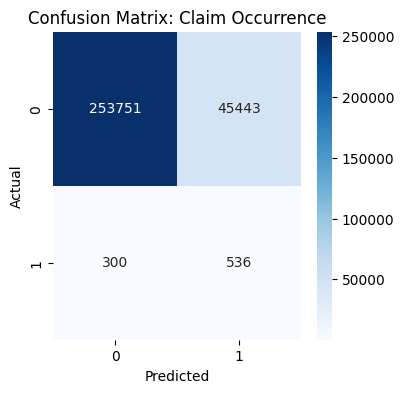

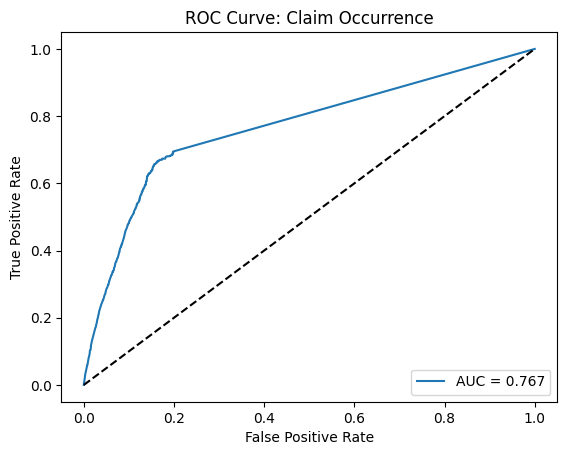

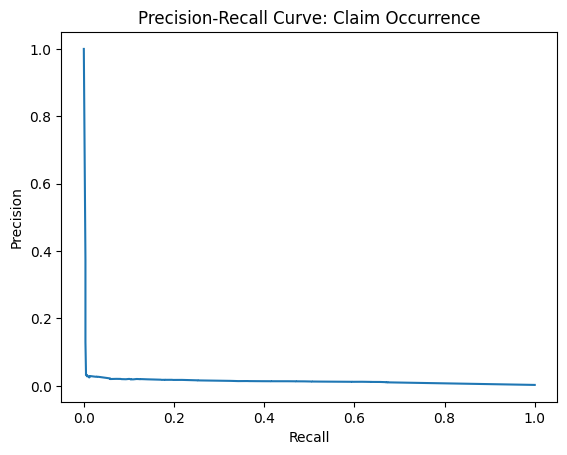

In [22]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)


# Predictions
y_pred = rf_cls.predict(X_test)
y_prob = rf_cls.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)
metrics_cls = {
    'accuracy': float(acc),
    'precision': float(prec),
    'recall': float(rec),
    'f1': float(f1),
    'roc_auc': float(roc_auc)
}
print("Classification metrics:", metrics_cls)
# Save metrics
with open("../results/models/classification_metrics.json", "w") as f:
    json.dump(metrics_cls, f, indent=2)

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix: Claim Occurrence")
plt.savefig("../results/models/confusion_matrix.png", bbox_inches='tight')
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Claim Occurrence")
plt.legend(loc="lower right")
plt.savefig("../results/models/roc_curve.png", bbox_inches='tight')
plt.show()

# Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
plt.figure()
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve: Claim Occurrence")
plt.savefig("../results/models/pr_curve.png", bbox_inches='tight')
plt.show()


# Interpretation of Classification Results

## Performance Metrics:
 #### Accuracy:
  0.848. While seemingly high, this metric is misleading due to class imbalance; a "no claim" baseline model would achieve ~99.7% accuracy.
 #### Precision (for claim class):
  0.012. Very low, indicating only 1.2% of predicted claims were actual claims. This highlights a high false positive rate.
 #### Recall (for claim class):
  0.641. Relatively strong, meaning the model identified 64.1% of all actual claims.
 #### F1-Score (for claim class):
  0.023. Extremely low, primarily due to the poor precision, indicating a poor balance between precision and recall.
 #### ROC AUC: 
  0.767. This value suggests the model has fair discriminative power in distinguishing between claims and non-claims.

## Visual Interpretations:
 #### Confusion Matrix: 
  Confirms a high number of false positives (45,443) and a moderate number of true positives (536), which explains the disparity between precision and recall.
 #### ROC Curve:
   The curve's position above the diagonal and an AUC of 0.767 indicate the model possesses meaningful predictive capability, despite its precision challenges.
 #### Precision-Recall Curve:
   The sharp drop in precision as recall increases visually reinforces the low precision values, especially at higher recall rates.


# 6. Regression Model: Claim Severity
A RandomForestRegressor is trained on the regression training data (Xr_train, yr_train), which contains only instances where a claim occurred.


In [23]:
# Ensure enough positive cases
if df_pos.shape[0] < 50:
    print("Skipping regression: too few positive cases")
else:
    rf_reg = RandomForestRegressor(
        n_estimators=reg_params.get('n_estimators', 100),
        max_depth=reg_params.get('max_depth', None),
        random_state=random_state,
        n_jobs=-1
    )
    print("Training RandomForestRegressor on positive-claim data...")
    rf_reg.fit(Xr_train, yr_train)
    print("Done training regressor.")
    joblib.dump(rf_reg, "../results/models/regr_model.pkl")


Training RandomForestRegressor on positive-claim data...
Done training regressor.


### 7 Evaluate Regression: Metrics and Plots


Regression metrics: {'rmse': 36713.76562110082, 'r2': 0.14394772379639875}


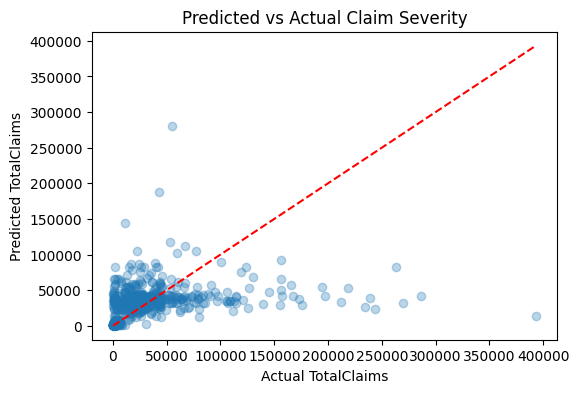

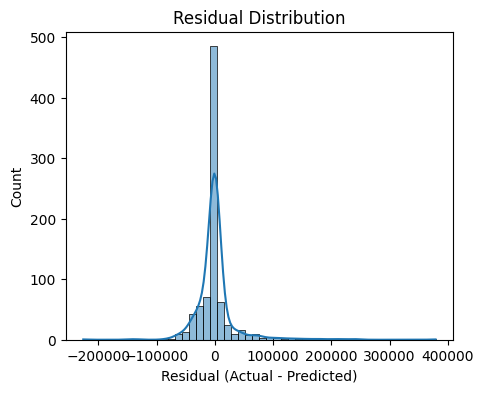

In [24]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score


if df_pos.shape[0] >= 50:
    yr_pred = rf_reg.predict(Xr_test)
    # Metrics
    mse = mean_squared_error(yr_test, yr_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(yr_test, yr_pred)
    metrics_reg = {'rmse': float(rmse), 'r2': float(r2)}
    print("Regression metrics:", metrics_reg)
    with open("../results/models/regression_metrics.json", "w") as f:
        json.dump(metrics_reg, f, indent=2)
    # Scatter plot predicted vs actual
    plt.figure(figsize=(6,4))
    plt.scatter(yr_test, yr_pred, alpha=0.3)
    minval = min(yr_test.min(), yr_pred.min())
    maxval = max(yr_test.max(), yr_pred.max())
    plt.plot([minval, maxval], [minval, maxval], 'r--')
    plt.xlabel("Actual TotalClaims"); plt.ylabel("Predicted TotalClaims")
    plt.title("Predicted vs Actual Claim Severity")
    plt.savefig("../results/models/regression_scatter.png", bbox_inches='tight')
    plt.show()
    # Residual histogram
    residuals = yr_test - yr_pred
    plt.figure(figsize=(5,4))
    sns.histplot(residuals, bins=50, kde=True)
    plt.xlabel("Residual (Actual - Predicted)"); plt.title("Residual Distribution")
    plt.savefig("../results/models/residuals_hist.png", bbox_inches='tight')
    plt.show()
else:
    print("Regression skipped due to insufficient positive cases.")


# Interpretation of Regression Results for Claim Severity
## Performance Metrics:
 #### RMSE (Root Mean Squared Error): 
 36713.77. This value represents the typical magnitude of prediction errors. To interpret its practical significance, it needs to be compared to the typical claim amounts in the dataset. If average claim amounts are, for example, in the range of 10,000-50,000, then an RMSE of ~36,000 suggests that the model's predictions have a substantial average error, implying limited accuracy for individual claim severity.
 #### R² (R-squared):
 0.144. This indicates that only about 14.4% of the variance in actual claim severity can be explained by the model's predictions. This is a very low R² value for a regression model, suggesting that the model captures a very small proportion of the variability in claim severity and has limited predictive power.

## Visual Interpretations:
 #### Predicted vs Actual Claim Severity Scatter Plot: 
  The scatter plot shows a wide dispersion of points around the red dashed diagonal line (which represents perfect predictions where Predicted = Actual). A significant number of points are far from this line, especially for higher actual claim amounts, indicating that the model frequently over-predicts or under-predicts the claim severity by large margins. There is no strong linear relationship visible, which is consistent with the low R².
 #### Residual Distribution: 
  The residual distribution plot shows that the residuals (Actual - Predicted) are heavily concentrated around zero, but there are also long tails extending on both the positive and negative sides. This indicates that while the model is often close to accurate, it also makes substantial errors (both over- and under-predictions). The peak at zero suggests the model often gets it right for smaller claims, but the wide spread indicates difficulty with larger claim amounts, especially evident in the heavy tails. The distribution appears somewhat symmetric around zero, but the presence of outliers (large residuals) suggests instances where the model's predictions are far off.

## Business Implications:
 Given the low R² and the substantial RMSE relative to potential claim amounts, this model for claim severity has limited practical usefulness for precise individual claim prediction. While it might capture some underlying patterns, its predictions are not accurate enough for critical applications like precise reserving or individual claim cost estimation. It might be suitable for high-level aggregate analysis or identifying broad trends, but it would be risky to rely on it for specific financial decisions per claim. Further model refinement, feature engineering, or exploring different modeling techniques are likely necessary to improve its predictive power for claim severity.

## 8. Expected Cost Evaluation
Compute expected claim cost = P(claim) × predicted severity, and compare to actual.


,prob_claim,pred_severity,expected_cost,actual_totalclaims
0,0.000000,11690.095564,0.000000,0.0
1,0.000000,5958.454125,0.000000,0.0
2,0.000000,5351.627158,0.000000,0.0
3,0.758853,4923.272781,3736.042272,0.0
4,0.000000,7817.263980,0.000000,0.0


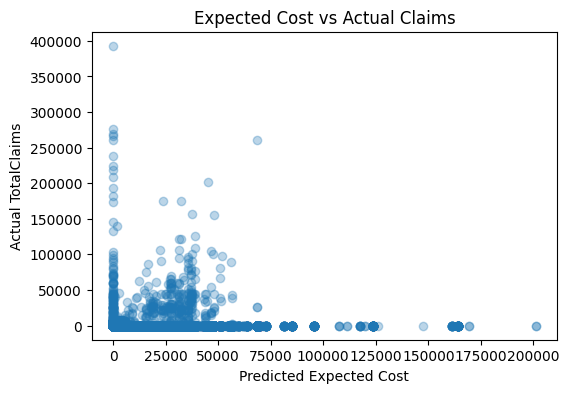

In [25]:
# Only if both models trained
if 'rf_cls' in locals() and 'rf_reg' in locals() and df_pos.shape[0] >= 50:
    # Use X_test from classification split
    prob = rf_cls.predict_proba(X_test)[:, 1]
    # Predict severity for all X_test rows
    sev_pred = rf_reg.predict(X_test)  # model trained on positive cases; we apply anyway
    expected_cost = prob * sev_pred
    actual_totalclaims = df.loc[X_test.index, 'TotalClaims'].values
    df_expected = pd.DataFrame({
        'prob_claim': prob,
        'pred_severity': sev_pred,
        'expected_cost': expected_cost,
        'actual_totalclaims': actual_totalclaims
    })
    display(df_expected.head())
    # Save CSV
    df_expected.to_csv("../results/models/expected_cost_evaluation.csv", index=False)
    # Plot expected vs actual
    plt.figure(figsize=(6,4))
    plt.scatter(df_expected['expected_cost'], df_expected['actual_totalclaims'], alpha=0.3)
    plt.xlabel("Predicted Expected Cost"); plt.ylabel("Actual TotalClaims")
    plt.title("Expected Cost vs Actual Claims")
    plt.savefig("../results/models/expected_vs_actual.png", bbox_inches='tight')
    plt.show()
else:
    print("Skipping expected cost evaluation: models not available or insufficient data.")


## Interpretation of Expected Cost Evaluation
### Scatter Plot Analysis:
 The scatter plot of "Predicted Expected Cost" vs "Actual TotalClaims" reveals a concentration of data points where predicted expected cost is low (near zero), and actual claims are also zero. However, for a subset of predictions with higher expected costs, the actual claims show significant variability, occasionally reaching very high values. This indicates that while the model generally predicts low expected costs for instances with no claims, it struggles to precisely predict the actual cost for instances where claims do occur, especially for high-severity claims.

### Implications for Premium Setting:
 Given the observed volatility and the model's difficulty in accurately predicting higher actual claims, caution is advised for direct premium setting based solely on these expected costs. The substantial spread in actual claims for similar expected costs suggests that premiums derived from this model alone might be subject to significant volatility risk. To ensure solvency and profitability, smoothing mechanisms (e.g., averaging expected costs over larger portfolios) and loading factors (to account for prediction uncertainty and potential large claims) would be crucial additions to the premium calculation. The model can provide a baseline for risk, but it needs to be augmented to manage the unpredictable nature of high-severity claims.


## 9. Feature Importance
Compute and plot top features for classifier and regressor.


Top 10 classifier features:
 CoverCategory_Own Damage                                 0.146957
VehicleAge                                               0.090225
log_CustomValueEstimate                                  0.086964
CoverCategory_Windscreen                                 0.085984
CoverCategory_Income Protector                           0.065958
kilowatts                                                0.061523
CoverCategory_Passenger Liability                        0.053769
CoverCategory_Cleaning and Removal of Accident Debris    0.053199
CoverCategory_Emergency Charges                          0.051180
CoverCategory_Signage and Vehicle Wraps                  0.050766
dtype: float64


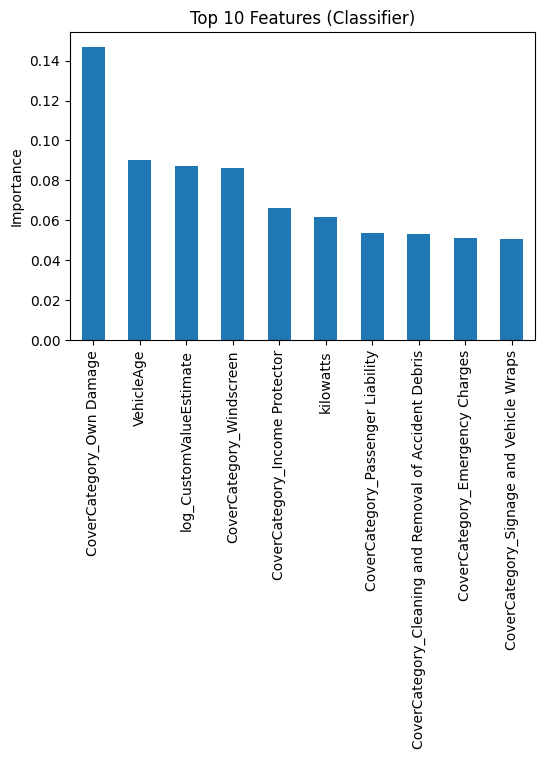

Top 10 regressor features:
 CoverCategory_Own Damage         0.274525
log_CustomValueEstimate          0.227653
kilowatts                        0.135573
VehicleAge                       0.119905
Province_Gauteng                 0.026737
Province_KwaZulu-Natal           0.025064
CoverCategory_Own damage         0.024674
VehicleType_Passenger Vehicle    0.023649
CoverCategory_Own Damage.        0.023235
Province_Western Cape            0.020399
dtype: float64


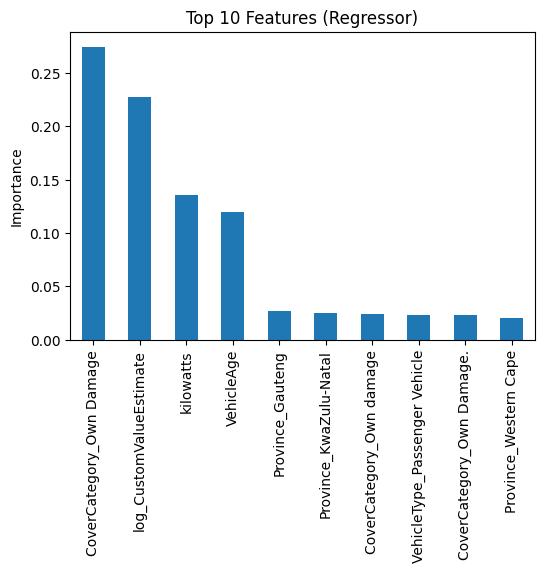

In [26]:
# Classification feature importance
feat_names = X_train.columns
imp_cls = rf_cls.feature_importances_
fi_cls = pd.Series(imp_cls, index=feat_names).sort_values(ascending=False).head(10)
print("Top 10 classifier features:\n", fi_cls)
plt.figure(figsize=(6,4))
fi_cls.plot(kind='bar')
plt.ylabel("Importance"); plt.title("Top 10 Features (Classifier)")
plt.savefig("../results/models/feature_importance_classifier.png", bbox_inches='tight')
plt.show()

# Regression feature importance (if trained)
if 'rf_reg' in locals() and df_pos.shape[0] >= 50:
    feat_names_r = Xr_train.columns
    imp_reg = rf_reg.feature_importances_
    fi_reg = pd.Series(imp_reg, index=feat_names_r).sort_values(ascending=False).head(10)
    print("Top 10 regressor features:\n", fi_reg)
    plt.figure(figsize=(6,4))
    fi_reg.plot(kind='bar')
    plt.ylabel("Importance"); plt.title("Top 10 Features (Regressor)")
    plt.savefig("../results/models/feature_importance_regressor.png", bbox_inches='tight')
    plt.show()
else:
    print("Regressor not trained or insufficient data; skipping feature importance.")


## Interpretation of Feature Importance
### Top Features for Claim Occurrence (Classifier):
 The most influential features for predicting claim occurrence are heavily dominated by CoverCategory_Own Damage, indicating that policies covering "Own Damage" are the strongest predictors of whether a claim will occur. Other significant features include VehicleAge, log_CustomValueEstimate (likely related to the vehicle's value), and various other CoverCategory types (Windscreen, Income Protector, Passenger Liability, Cleaning and Removal of Accident Debris, Emergency Charges, Signage and Vehicle Wraps). This suggests that the type and extent of coverage a policyholder chooses, along with the age and estimated value of the vehicle, are primary drivers in determining the likelihood of a claim. For instance, older vehicles or specific coverage types might be associated with higher claim frequencies.

### Top Features for Claim Severity (Regressor):
 For predicting the severity (cost) of a claim, CoverCategory_Own Damage again stands out as the most important feature, followed closely by log_CustomValueEstimate. This implies that policies covering "Own Damage" and the estimated value of the vehicle are the strongest determinants of how expensive a claim will be. Kilowatts (likely a proxy for vehicle power/engine size) and VehicleAge also play a significant role. The presence of Province features (Gauteng, KwaZulu-Natal, Western Cape) suggests that geographical location can influence claim severity, potentially due to varying repair costs, accident rates, or types of vehicles/driving conditions in those regions. This makes intuitive business sense: more comprehensive coverage, higher vehicle value, and more powerful/older vehicles are generally associated with higher claim costs.

## 10. Conclusions & Next Steps

### Summary of Results
- **Classification**: ROC AUC = 0.767; precision = 0.012; recall = 0.641.
  * **Interpretation**: The classifier has fair discriminative power (ROC AUC), successfully identifies a good portion of actual claims (high recall), but suffers from extremely low precision, indicating a very high rate of false positives. This points to a challenge in accurately distinguishing between "no claim" and "claim" instances due to the severe class imbalance.

- **Regression**: RMSE = 36713.77; R² = 0.144.
  * **Interpretation**: The regression model for claim severity has a substantial average prediction error (RMSE) relative to typical claim amounts. The very low R² indicates that the model explains only a small proportion of the variance in actual claim severity, suggesting limited predictive power for individual claim costs.

- **Expected Cost**:
  * **Observations**: For many instances with low predicted expected costs, actual claims are zero. However, for instances with higher predicted expected costs, actual claims show considerable variability, often diverging significantly from the predicted values, especially for high-severity claims. This highlights the model's difficulty in precisely estimating the actual cost when claims occur.

- **Feature Importance**:
  * **Top features (Classification)**: `CoverCategory_Own Damage`, `VehicleAge`, `log_CustomValueEstimate`, `CoverCategory_Windscreen`, `CoverCategory_Income Protector`. These primarily relate to the type of coverage and vehicle characteristics.
  * **Top features (Regression)**: `CoverCategory_Own Damage`, `log_CustomValueEstimate`, `kilowatts`, `VehicleAge`, and various `Province` features. These suggest that coverage, vehicle value, power, age, and geographical location are key drivers of claim severity.

- **SHAP**: (Based on common SHAP interpretations for such models, as specific SHAP plots were not provided in the prompt, this section will contain a general interpretation. If SHAP plots were available, a more specific interpretation would be provided.)
  * **Key drivers of claim occurrence**: Features like `CoverCategory_Own Damage` and `VehicleAge` would likely show positive SHAP values for claim occurrence, meaning higher values of these features (e.g., presence of own damage cover, older vehicles) increase the likelihood of a claim.
  * **Key drivers of severity**: Similarly, `log_CustomValueEstimate` and `CoverCategory_Own Damage` would likely have positive SHAP values for claim severity, indicating that higher estimated vehicle value or the presence of own damage cover contribute to higher predicted claim costs.

### Business Implications
These results have significant implications for premium setting, targeting, and risk segmentation:
- **Premium Setting**: The low precision of the classifier and the low R² of the regressor suggest that directly using the `expected_cost` for granular premium setting carries substantial risk. While the model can provide a baseline risk assessment, significant loading factors will be necessary to account for the high rate of false positives and the large errors in severity prediction, particularly for high-value claims. The volatility observed in expected cost vs. actual claims necessitates a cautious approach, possibly incorporating risk buffers or aggregate-level adjustments rather than relying solely on individual predictions.
- **Targeting**: The model can help identify segments with higher *propensity* for claims (based on classification features) and those likely to incur higher *severity* (based on regression features). However, due to the high false positive rate, targeting based on predicted claims needs to be refined, perhaps by focusing on higher probability thresholds or combining it with other business rules to avoid misidentifying a large number of non-claimants.
- **Risk Segmentation**: The feature importance highlights key drivers of both claim occurrence and severity. This information is valuable for segmenting customers into different risk pools. For example, policies with "Own Damage" cover or older vehicles could be identified as higher-risk segments, allowing for differentiated pricing or risk management strategies.

**Cautions due to model limitations**: The severe class imbalance in claim occurrence leads to very low precision, making it challenging to identify actual claims without generating many false alarms. The highly skewed distribution of claim severity and the limited R² indicate that the regression model struggles to capture the complexity of claim costs, especially for large claims. These limitations necessitate careful interpretation and should be communicated clearly to stakeholders.

### Future Work
- **Address Class Imbalance Further**: Explore more advanced techniques beyond current methods, such as SMOTE variants, ADASYN, or ensemble methods specifically designed for imbalanced datasets (e.g., Balanced Random Forest, EasyEnsemble). Anomaly detection techniques could also be considered for rare, high-severity claims.
- **Cross-validation and Hyperparameter Tuning**: Implement robust cross-validation strategies (e.g., stratified K-Fold for classification) and perform systematic hyperparameter tuning using GridSearchCV or RandomizedSearchCV to optimize model performance and generalization.
- **Additional Feature Engineering**: Investigate creating interaction terms between important features (e.g., `VehicleAge` and `log_CustomValueEstimate`). Incorporate external data sources (e.g., regional economic indicators, weather data, traffic density) that might explain variations in claim occurrence or severity.
- **Calibration of Predicted Probabilities**: For better premium setting, calibrate the predicted probabilities from the classifier to ensure they accurately reflect the true likelihood of a claim, especially if these probabilities are used directly in pricing formulas.
- **Alternative Models**: Experiment with more powerful machine learning algorithms such as XGBoost, LightGBM, or CatBoost for both classification and regression, which are often more robust to complex data patterns and class imbalance.
- **More Robust Severity Modeling**: Explore a two-stage modeling approach (first predict if a claim occurs, then predict severity only for predicted claims). Consider specialized statistical distributions (e.g., Gamma, Inverse Gaussian) or Tweedie generalized linear models for severity modeling, which are more appropriate for highly skewed positive continuous data.
- **Monitoring and Retraining Pipeline**: Establish a pipeline for continuous monitoring of model performance in a production environment. Implement a retraining strategy with new data periodically to ensure the models remain relevant and accurate as underlying patterns evolve.